# Matplotlib: Core Plot Types

 This notebook goes through those same four plot types in proper depth, plus three more you'll meet in real work: box plots, violin plots, and pie charts.

**What you'll learn:**
1. Line plots — line styles, widths, markers, when to use them
2. Scatter plots — encoding four dimensions in one chart
3. Bar charts — vertical, horizontal, grouped, stacked
4. Histograms — the shape of a single variable
5. Box plots and violin plots — comparing distributions across groups
6. Pie charts — how to make one and why you usually shouldn't
7. A reference table for picking the right plot type

## What "plot type" means

The phrase **plot type** refers to the visual form of a chart — line, bar, scatter, and so on. Picking the wrong one is the single biggest mistake in data viz: a perfectly correct bar chart for time-series data still misleads the reader, because bars suggest discrete categories rather than a continuous trend.

The right way to pick a plot type is to start from the question you want the reader to answer:

- "How did this change over time?" — line plot
- "Are these two variables related?" — scatter plot
- "Which category has the most?" — bar chart
- "What does the distribution look like?" — histogram, box plot, or violin plot
- "How do groups compare?" — grouped bars, multiple histograms, or box plots side by side

The sections below cover each of these in depth.

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

## Line Plots

A **line plot** connects data points in order with a straight line between each pair. Use it whenever the x-axis represents something with a meaningful order — time, position along a path, an input variable swept across a range. The line lets the reader trace a value as it moves through that ordering.

Three things you can control on every line:

- `color` — accepts a string name (`'red'`, `'steelblue'`), a hex code (`'#FF5733'`), or a cycle position (`'C0'`, `'C1'`).
- `linewidth` (or `lw`) — the thickness of the line, in points. Default is 1.5; bump to 2 or 2.5 for slides and posters.
- `linestyle` (or `ls`) — solid (`'-'`), dashed (`'--'`), dash-dot (`'-.'`), or dotted (`':'`). Use different styles when several lines need to be distinguishable in greyscale or for colorblind readers.

The cell below draws three curves on the same axes: a solid blue sine, a dashed crimson cosine, and a dotted green damped sine.

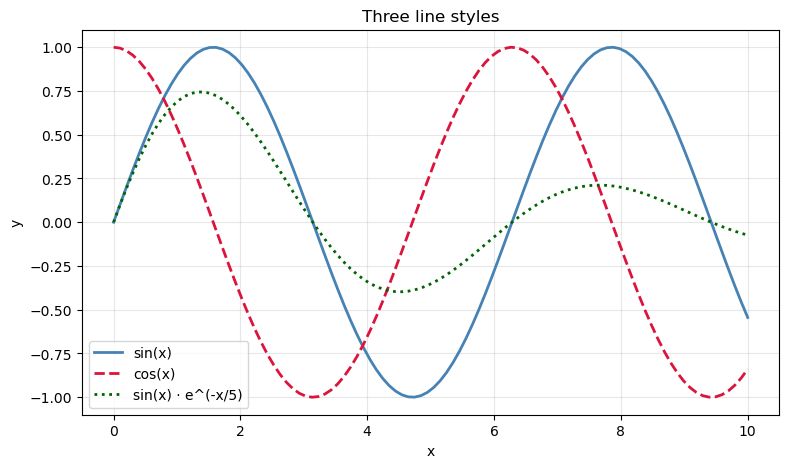

In [21]:
x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, np.sin(x),
        color='steelblue',
        linewidth=2,
        linestyle='-',
        label='sin(x)')

ax.plot(x, np.cos(x),
        color='crimson',
        linewidth=2,
        linestyle='--',
        label='cos(x)')

ax.plot(x, np.sin(x) * np.exp(-x/5),
        color='darkgreen',
        linewidth=2,
        linestyle=':',
        label='sin(x) · e^(-x/5)')

ax.set_title("Three line styles")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


- `x = np.linspace(0, 10, 100)` creates 100 evenly spaced x-values from 0 to 10. The same `x` is reused for all three lines so they share the horizontal axis.
- Each `ax.plot(...)` call draws one line and gives it a `label`. Spreading the keyword arguments onto separate lines is a readability choice — matplotlib accepts everything on one line too.
- `np.sin(x) * np.exp(-x/5)` is a damped sine: the sine wave multiplied by an exponentially shrinking envelope. The line gets quieter as `x` grows.
- `ax.legend()` reads the `label=` strings from each plot call and draws a legend.
- `ax.grid(True, alpha=0.3)` adds faint background gridlines. The alpha keeps them subtle so they don't compete with the data.
- `plt.show()` renders the figure inline below the cell.

### Line style options at a glance

| Argument | Common values |
|---|---|
| `color` | `'red'`, `'#FF5733'`, `'C0'`, `'C1'`, ... |
| `linestyle` (or `ls`) | `'-'`, `'--'`, `'-.'`, `':'` |
| `linewidth` (or `lw`) | Float, default 1.5 |
| `marker` | `'o'`, `'s'`, `'^'`, `'x'`, `'+'`, `'*'` |
| `markersize` (or `ms`) | Float |
| `alpha` | 0.0 to 1.0 (transparency) |

### Adding markers to a line

A **marker** is a small shape — a circle, square, triangle, and so on — drawn at every data point along the line. Markers help the reader see exactly where each measured value sits when the line connects them. Without markers, the eye assumes data is continuous; with markers, it sees a discrete sequence joined by the line.

The most common marker shapes:

| Code | Shape |
|---|---|
| `'o'` | filled circle |
| `'s'` | filled square |
| `'^'` | upward triangle |
| `'x'` | cross |
| `'+'` | plus |
| `'*'` | star |

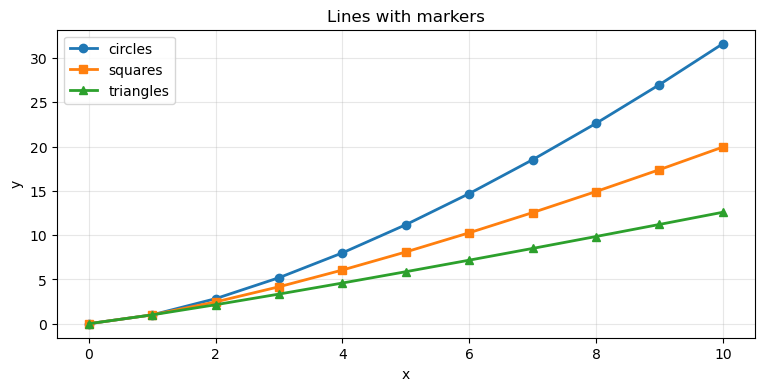

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(0, 11)
ax.plot(x, x**1.5, marker='o', linewidth=2, label='circles')
ax.plot(x, x**1.3, marker='s', linewidth=2, label='squares')
ax.plot(x, x**1.1, marker='^', linewidth=2, label='triangles')
ax.set_title("Lines with markers")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

- `np.arange(0, 11)` produces the integers 0 through 10 (the endpoint is exclusive). Markers look more useful at a small number of widely-spaced points than at the 100-point dense lines from the previous example.
- `marker='o'` (and `'s'`, `'^'`) is the only new argument. Every other part of the call works exactly as before.
- A marker is drawn at every value in the x array. If you wanted markers only at certain points, you'd use `markevery=5` to draw one every fifth point.

## Scatter Plots

A **scatter plot** draws one dot per data point with no line connecting them. The lack of a line is the entire point: lines imply an order between consecutive points, and a scatter is what you use when there *is* no order — just a cloud of unrelated (x, y) pairs.

The classic use is checking whether two variables are related. If the cloud looks like a tilted line, the variables are correlated; if it looks like a fuzzy circle, they aren't. Beyond that, you can encode extra dimensions by varying the dot size and color, so a single scatter can show up to four variables at once.

The cell below plots a basic scatter — 200 random points where `y` is roughly `2x` plus noise.

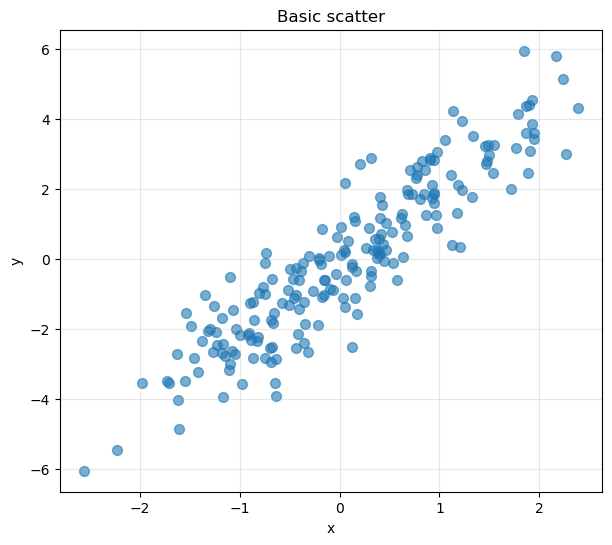

In [23]:
np.random.seed(0)
n = 200
x = np.random.randn(n)
y = 2 * x + np.random.randn(n)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y, alpha=0.6, s=50)
ax.set_title("Basic scatter")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
plt.show()


- `np.random.randn(n)` draws `n` samples from a standard normal distribution (mean 0, standard deviation 1). The seeded RNG (`np.random.seed(0)`) makes the run reproducible.
- `y = 2 * x + np.random.randn(n)` builds a noisy linear relationship: y is approximately twice x, plus normally distributed noise. The cloud should look tilted up at roughly a 2:1 slope.
- `ax.scatter(x, y, alpha=0.6, s=50)` is the scatter call.
  - `s=50` is the marker size in square points. Default is around 36; 50 here is slightly larger.
  - `alpha=0.6` makes each dot semi-transparent. With 200 points and some overlap, full opacity would hide whatever sits underneath; transparency reveals density (darker spots have more overlapping points).

### Encoding more dimensions

A scatter plot can carry up to four variables at once if you use the available channels:

- **x position** — first variable
- **y position** — second variable
- **dot size** (`s=...`) — third variable, mapped to area
- **dot color** (`c=...`, with a `cmap=`) — fourth variable, mapped through a colormap

The next cell uses all four.

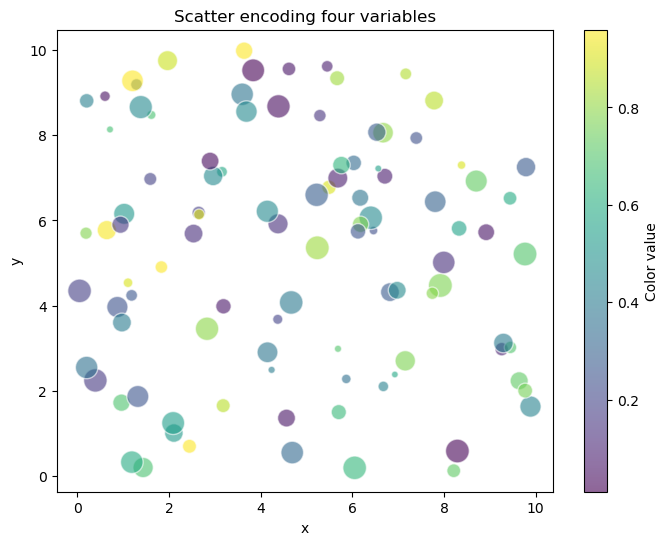

In [24]:
np.random.seed(0)
n = 100
x = np.random.uniform(0, 10, n)
y = np.random.uniform(0, 10, n)
sizes = np.random.uniform(20, 300, n)
colors = np.random.uniform(0, 1, n)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(x, y, s=sizes, c=colors, alpha=0.6,
                     cmap='viridis', edgecolors='white')
fig.colorbar(scatter, ax=ax, label='Color value')
ax.set_title("Scatter encoding four variables")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


- `np.random.uniform(low, high, n)` draws `n` samples uniformly between `low` and `high`. Used here so points spread evenly rather than clustering in the middle the way `randn` would.
- `s=sizes` and `c=colors` are the two extra channels. `s` accepts an array of sizes (one per point); `c` accepts an array of numeric values that get mapped through the colormap to actual colors.
- `cmap='viridis'` is the recommended sequential colormap — perceptually uniform and colorblind-friendly.
- `edgecolors='white'` outlines every dot with a thin white border. This is what keeps overlapping dots visually distinct instead of merging into one blob.
- `fig.colorbar(scatter, ax=ax, label='Color value')` adds the gradient legend on the right. It needs:
  - `scatter` — the return value of `ax.scatter`, so the colorbar knows the value range and colormap.
  - `ax=ax` — which axes to steal space from.
  - `label='Color value'` — the colorbar's own label, so the reader knows what the gradient means.

### Coloring scatter points by category

The pattern above uses a continuous third variable. Often you have categories instead — three classes, four product lines — and want each group in its own solid color. The pattern then is to plot one `scatter` call per group, each with its own `color` and `label`.

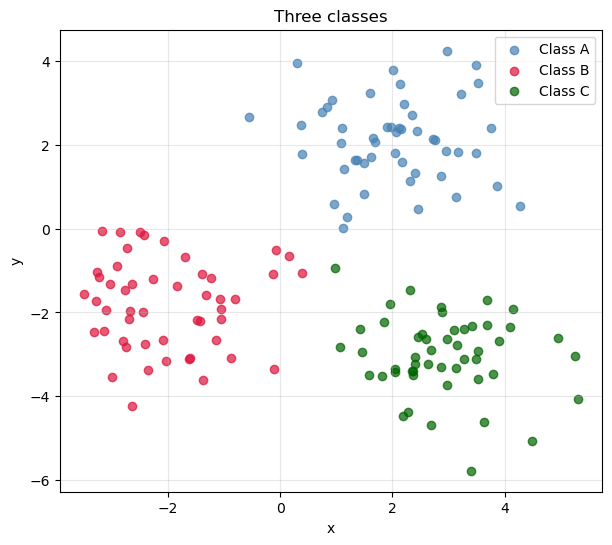

In [25]:
np.random.seed(0)
class_a = np.random.randn(50, 2) + [2, 2]
class_b = np.random.randn(50, 2) + [-2, -2]
class_c = np.random.randn(50, 2) + [3, -3]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(class_a[:, 0], class_a[:, 1], color='steelblue', alpha=0.7, label='Class A')
ax.scatter(class_b[:, 0], class_b[:, 1], color='crimson',   alpha=0.7, label='Class B')
ax.scatter(class_c[:, 0], class_c[:, 1], color='darkgreen', alpha=0.7, label='Class C')
ax.set_title("Three classes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

**Reading the code:**

- `np.random.randn(50, 2) + [2, 2]` produces 50 two-dimensional points centered at (2, 2). The `+ [2, 2]` shifts every point by adding 2 to both coordinates — broadcasting in action.
- Each class has its own scatter call with its own `color`. The categorical version of "color by group" is many simple calls rather than one call with a `c=` array.
- `class_a[:, 0]` is the first column (the x-values); `class_a[:, 1]` is the second column (the y-values). The `[:, n]` syntax means "all rows, column n".
- The legend pulls labels from each `scatter` call exactly the way it does from `plot`.

## Bar Charts

A **bar chart** uses one bar per category, with each bar's length showing the value. Use it when the x-axis is a set of discrete categories — products, countries, departments, weekdays — and you want the reader to compare their values directly.

A common mistake is to use bars for time series (one bar per day or week). Time is continuous, not categorical, so a line plot is almost always clearer for it. Reach for bars when the categories have no natural order and the only thing the reader needs to do is compare heights.

This section covers four flavors:

- **Vertical bars** — the default. Best when category names are short.
- **Horizontal bars** — same chart rotated 90°. Best when category names are long enough that horizontal text would overlap.
- **Grouped bars** — multiple bars per category, side by side. Best for comparing a small number of sub-categories within each main category.
- **Stacked bars** — multiple values per category piled on top of each other. Best when the parts add up to a meaningful total.

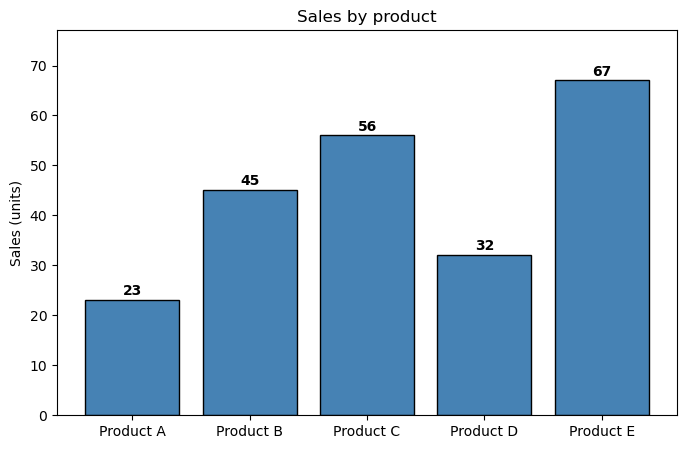

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
sales = [23, 45, 56, 32, 67]

bars = ax.bar(categories, sales, color='steelblue', edgecolor='black')

for bar, value in zip(bars, sales): # zip pairs up corresponding elements from two (or more) iterables and lets you loop over them together.
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(value),
            ha='center',
            fontweight='bold')

ax.set_title("Sales by product")
ax.set_ylabel("Sales (units)")
ax.set_ylim(0, max(sales) * 1.15)
plt.show()

**Reading the code:**

- `ax.bar(categories, sales, color='steelblue', edgecolor='black')` draws the bars. The first argument is the category list (also used as x-axis labels); the second is the heights. The call returns a list of bar objects, captured here as `bars` so we can iterate over them.
- The `for bar, value in zip(bars, sales)` loop writes the numeric value on top of each bar.
  - `bar.get_x()` is the bar's left edge; `bar.get_width()/2` shifts to its center. Together they give the bar's horizontal center.
  - `bar.get_height() + 1` puts the text one unit above the bar's top.
  - `ha='center'` centers the text horizontally around the chosen x-coordinate.
- `ax.set_ylim(0, max(sales) * 1.15)` extends the y-axis 15% beyond the tallest bar so the value label has room to sit above without being clipped. Without this padding, the topmost label can collide with the axis edge.

### Horizontal bars

When the category names are long, vertical bars cause the labels to overlap or rotate awkwardly. Rotating the whole chart 90° — using `ax.barh` instead of `ax.bar` — solves it: the labels run along the y-axis where they have room to stretch.

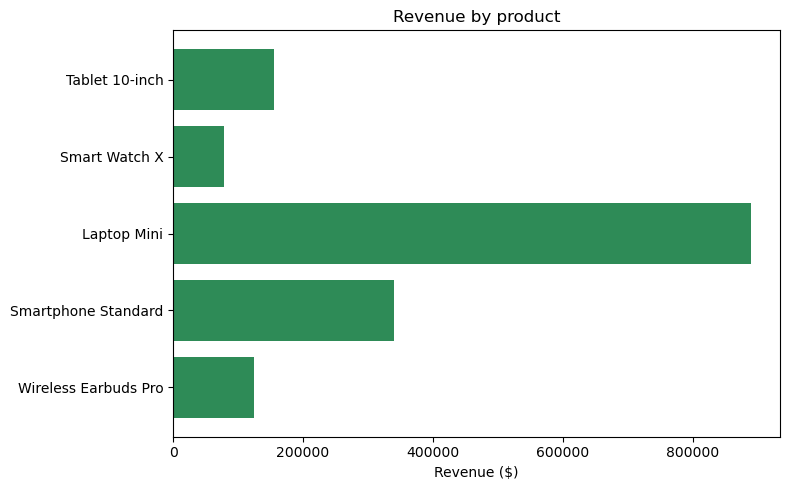

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
products = ['Wireless Earbuds Pro', 'Smartphone Standard', 'Laptop Mini',
            'Smart Watch X', 'Tablet 10-inch']
revenue = [125000, 340000, 890000, 78000, 156000]

ax.barh(products, revenue, color='seagreen')
ax.set_title("Revenue by product")
ax.set_xlabel("Revenue ($)")
ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()


- `ax.barh(products, revenue, color='seagreen')` is the horizontal version of `ax.bar`. Its arguments are the category labels (now on the y-axis) and the bar lengths (now along the x-axis).
- `ax.ticklabel_format(style='plain', axis='x')` forces the x-axis to print numbers as `890000` rather than the scientific notation matplotlib sometimes picks for large values (`8.9e5`).
- `plt.tight_layout()` is essential here — the long product names need extra horizontal space on the left, and `tight_layout` ensures matplotlib widens the left margin enough to fit them without clipping.

### Grouped bars

When you want to compare multiple sub-categories *within* each main category (three products tracked across four quarters, for example), grouped bars put the sub-bars side by side. The tricky part is positioning: you need to offset each group of bars left and right of the category's center.

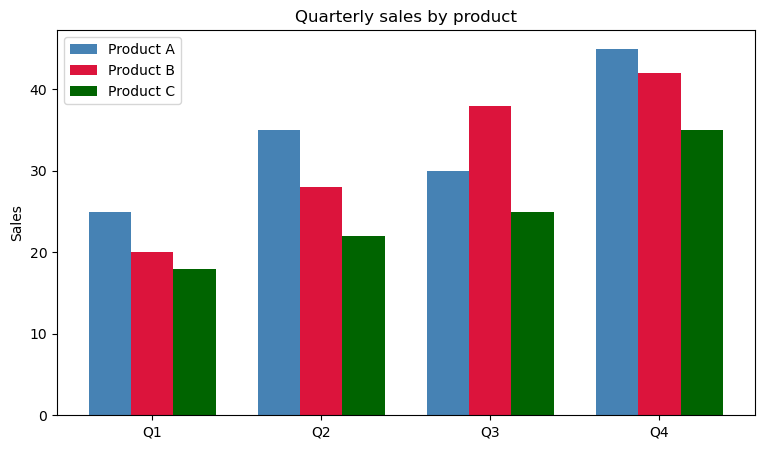

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [25, 35, 30, 45]
product_b = [20, 28, 38, 42]
product_c = [18, 22, 25, 35]

x = np.arange(len(categories))
width = 0.25

ax.bar(x - width, product_a, width, label='Product A', color='steelblue')
ax.bar(x,         product_b, width, label='Product B', color='crimson')
ax.bar(x + width, product_c, width, label='Product C', color='darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title("Quarterly sales by product")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

- `x = np.arange(len(categories))` produces the integer positions `[0, 1, 2, 3]` — one per quarter. Each group of three bars will be centered at one of these positions.
- `width = 0.25` is the width of a single bar. With three bars per group, the group spans `3 × 0.25 = 0.75` units, fitting comfortably between adjacent group centers (which are 1 unit apart).
- `ax.bar(x - width, product_a, width, ...)` places Product A's bars at `x - 0.25` — one bar-width to the left of each group's center.
- `ax.bar(x, product_b, width, ...)` places Product B's bars right at the group center.
- `ax.bar(x + width, product_c, width, ...)` places Product C's bars to the right.
- `ax.set_xticks(x)` puts the tick marks at the group centers, and `ax.set_xticklabels(categories)` labels them `Q1`, `Q2`, etc. — instead of the default `0, 1, 2, 3`.

### Stacked bars

A **stacked bar chart** piles multiple values on top of each other so each bar represents a total broken into parts. Use it when the parts add up to something meaningful — total sales split by product, total population split by age group. Avoid it when you actually want to compare the individual values directly; reading sub-bars at different baselines is harder than comparing side-by-side bars.

The key argument is `bottom=` — it tells matplotlib where the current set of bars should start vertically, so each new layer sits on top of the previous total.

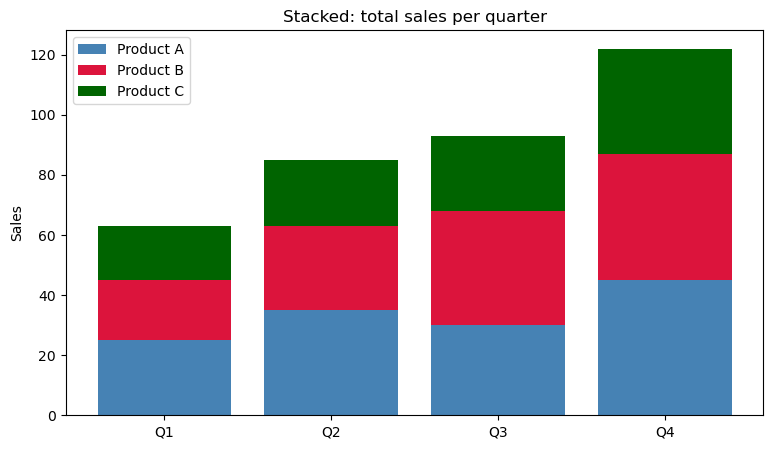

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = np.array([25, 35, 30, 45])
product_b = np.array([20, 28, 38, 42])
product_c = np.array([18, 22, 25, 35])

ax.bar(categories, product_a, label='Product A', color='steelblue')
ax.bar(categories, product_b, bottom=product_a,             label='Product B', color='crimson')
ax.bar(categories, product_c, bottom=product_a + product_b, label='Product C', color='darkgreen')

ax.set_title("Stacked: total sales per quarter")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

- The first `ax.bar` call draws Product A from y=0 up to its heights. No `bottom=` argument — matplotlib defaults to 0.
- The second call adds Product B with `bottom=product_a`. NumPy broadcasting means `bottom` accepts an array — each quarter's Product B bar starts where that quarter's Product A bar ended.
- The third call adds Product C with `bottom=product_a + product_b`. NumPy adds the two arrays element-wise, so Product C's bars sit on top of the combined Product A and B totals.
- The lists were converted to `np.array(...)` so that `product_a + product_b` does element-wise arithmetic rather than list concatenation.

## Histograms — Distribution of One Variable

A **histogram** takes a list of numbers, divides the range into intervals called **bins**, and draws one bar per bin with height equal to the count of values that fell into it. The result is a picture of *how the numbers are spread out* — where they cluster, whether they're symmetric, whether they're tightly grouped or widely scattered.

This is different from a bar chart in an important way: a bar chart compares values across categories, while a histogram shows the distribution of a single numerical variable. The visual is the same — rectangles of varying heights — but what they mean is completely different.

The most important argument is `bins`. Too few bins hide structure; too many bins make the histogram look noisy. Common rules of thumb:

- The default of `bins=10` is rarely right for any real dataset.
- Try `bins=30` as a first guess.
- For very large samples (10,000+), `bins=50` or `bins=int(np.sqrt(len(data)))` works well.

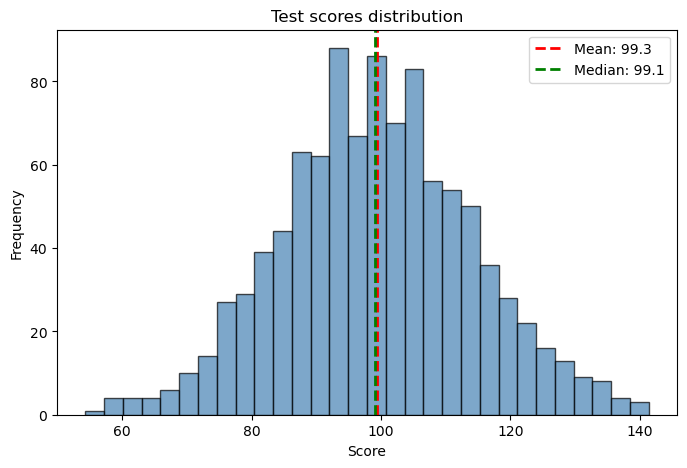

In [30]:
np.random.seed(0)
data = np.random.normal(100, 15, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title("Test scores distribution")
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")

ax.axvline(data.mean(),     color='red',   linestyle='--', linewidth=2, label=f'Mean: {data.mean():.1f}')
ax.axvline(np.median(data), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(data):.1f}')
ax.legend()
plt.show()

- `np.random.normal(100, 15, 1000)` draws 1000 samples from a normal distribution with mean 100 and standard deviation 15 — a typical test-score-like distribution.
- `ax.hist(data, bins=30, ...)` divides the range from min to max into 30 equal-width intervals and counts how many values fall into each.
  - `edgecolor='black'` draws a thin black border around each bar. Without it, adjacent bars can blur together visually.
  - `alpha=0.7` makes the bars slightly transparent. This matters more in the next example, where two histograms overlap.
- `ax.axvline(data.mean(), ...)` draws a vertical line at the sample mean. `axvline` is the vertical counterpart to `axhline`. The dashed red line at the mean and dashed green line at the median give the reader two summary statistics to interpret the histogram with.
- `f'Mean: {data.mean():.1f}'` is an f-string with format spec `:.1f` — "format as float with one decimal place."

### Comparing two distributions

To compare two distributions, plot them on the same axes with `alpha` low enough that the overlap is visible. Two solid histograms hide each other; two semi-transparent ones reveal where they overlap and where they differ.

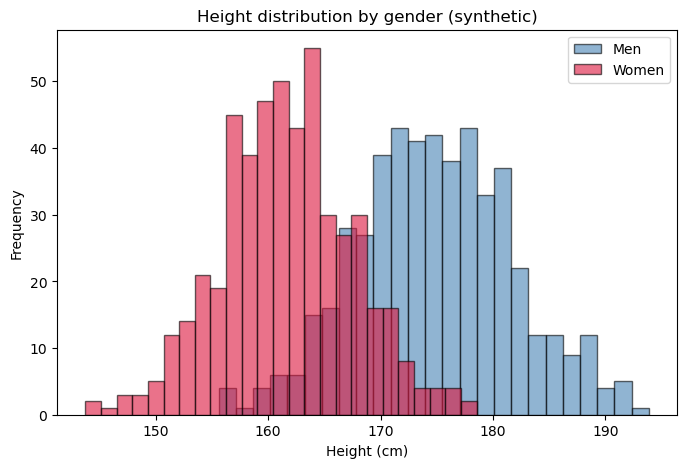

In [31]:
np.random.seed(0)
men   = np.random.normal(175, 7, 500)
women = np.random.normal(162, 6, 500)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(men,   bins=25, alpha=0.6, label='Men',   color='steelblue', edgecolor='black')
ax.hist(women, bins=25, alpha=0.6, label='Women', color='crimson',   edgecolor='black')
ax.set_title("Height distribution by gender (synthetic)")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

Two `ax.hist` calls draw both distributions on the same axes.

- `alpha=0.6` is essential. With solid bars one distribution would hide the other; transparency lets both show through where they overlap, and the overlap region appears in a blended color.
- Each histogram uses its own `bins=25` — matplotlib computes the bin edges independently from each dataset's range. If you want both to share identical bin edges, pass a pre-computed array like `bins=np.linspace(150, 195, 26)` to both calls.
- The colors are picked to be distinguishable when blended: steelblue and crimson sit far apart on the color wheel so the overlap is a visible purple.

## Box Plots and Violin Plots — Comparing Distributions

When you want to compare a distribution across several groups — test scores in four classes, weights at three ages, response times on five servers — overlaid histograms become unreadable around the third group. A **box plot** is the standard summary that solves this: each group becomes a compact box-and-whiskers diagram, and the boxes sit side by side for easy comparison.

A box plot reduces a whole distribution to five numbers:

```
                ┌─────┐
                │     │  ← upper whisker (highest value still considered normal)
                │  ●  │  ← outliers (drawn as individual dots)
        ━━━━━━━━┯━━━━━━━━  ← Q3 (75th percentile)
        ┃               ┃
        ┃    median     ┃  ← Q2 (50th percentile, the line through the middle)
        ┃               ┃
        ━━━━━━━━┷━━━━━━━━  ← Q1 (25th percentile)
                │     │  ← lower whisker (lowest value still considered normal)
                └─────┘
```

- The **box** spans from the 25th to the 75th percentile — it contains the middle 50% of the data.
- The **line through the box** is the median.
- The **whiskers** extend to the most extreme values that aren't outliers (usually defined as anything within 1.5× the box height past the box).
- Points beyond the whiskers are drawn individually as outliers.

A **violin plot** is a richer alternative. Instead of a box, each group is drawn as a smoothed version of its histogram, mirrored around a vertical axis (the shape resembles a violin, hence the name). Box plots are crisper and easier to compare; violin plots show distribution shape — bimodality, skew, fat tails — that boxes hide.

C:\Users\hp\AppData\Local\Temp\ipykernel_74404\418973677.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


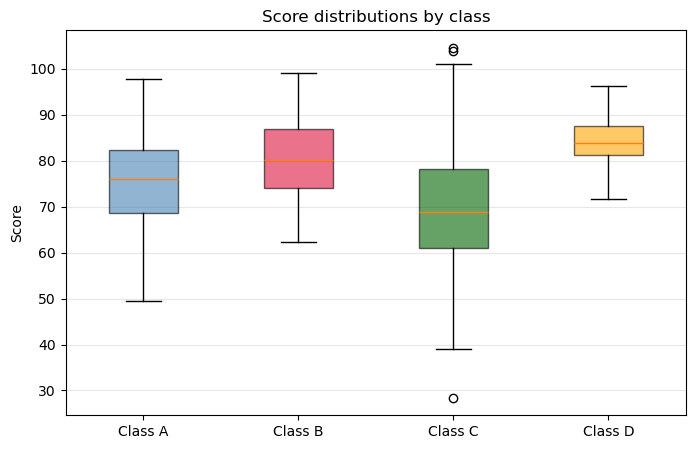

In [32]:
np.random.seed(0)
data = [
    np.random.normal(75, 10, 100),
    np.random.normal(80,  8, 100),
    np.random.normal(70, 15, 100),
    np.random.normal(85,  5, 100),
]
labels = ['Class A', 'Class B', 'Class C', 'Class D']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, labels=labels, patch_artist=True)

colors = ['steelblue', 'crimson', 'darkgreen', 'orange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title("Score distributions by class")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.3, axis='y')
plt.show()

- `data` is a list of NumPy arrays — one array per group. `ax.boxplot` accepts this directly.
- `np.random.normal(mean, std, 100)` produces 100 samples per class with different means (typical score) and different standard deviations (spread). Class C has the widest spread; Class D has the tightest.
- `patch_artist=True` is the toggle that makes each box fillable with color. Without it the boxes are just outlines.
- The loop iterates over `bp['boxes']` — the box objects returned by `boxplot` — and colors each one. `bp` is a dictionary with keys like `'boxes'`, `'whiskers'`, `'caps'`, `'medians'`, `'fliers'` (the outliers), so you can style each piece independently.
- `axis='y'` on the grid restricts gridlines to horizontal ones only. Vertical gridlines through the boxes would be noise.

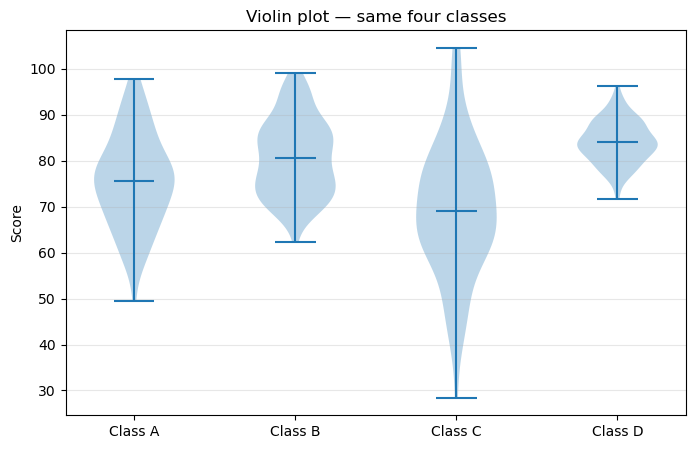

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot(data, showmeans=True, showmedians=False)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels)
ax.set_title("Violin plot — same four classes")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.3, axis='y')
plt.show()


- `ax.violinplot(data, showmeans=True, showmedians=False)` takes the same list-of-arrays as `boxplot`. The two boolean arguments toggle the small horizontal lines drawn across each violin:
  - `showmeans=True` adds a line at each group's mean.
  - `showmedians=False` suppresses the median line in this example.
- Unlike `boxplot`, `violinplot` does not accept a `labels` argument. The conventional workaround is to set the x-tick positions to `range(1, n+1)` (matching the default positions matplotlib uses for `n` violins) and provide custom x-tick labels separately.

The wider parts of each violin show where the data is densest. Compare Class C (wide spread, fat middle) with Class D (tightly packed, narrow violin) — that contrast is much harder to spot from a box plot alone.

## Pie Charts

A **pie chart** divides a circle into wedges, one wedge per category, with each wedge's angle proportional to the category's value. Pie charts are visually familiar, but they're rarely the best choice in practice:

- Humans are bad at comparing angles. Telling whether a wedge is 17% or 22% takes real effort.
- They break down past about five categories — slim wedges all start looking the same.
- Sorted horizontal bars convey the same information in a few seconds of glance time.

That said, you'll be asked to make one occasionally (a stakeholder requests it, the data really is a small handful of parts). When that happens, here's the recipe.

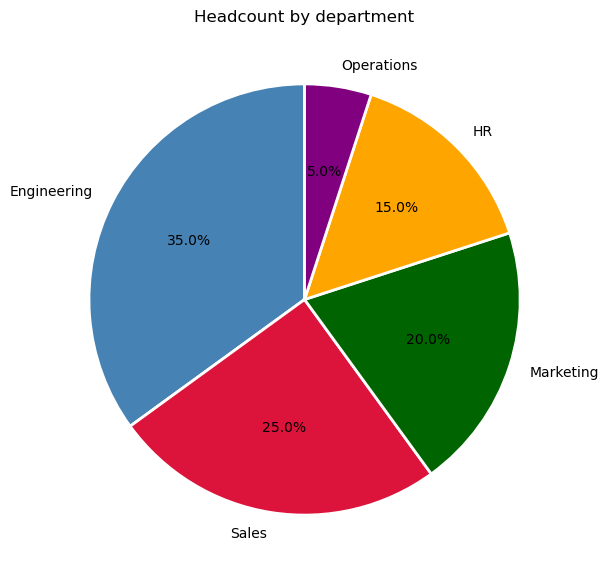

In [34]:
sizes  = [35, 25, 20, 15, 5]
labels = ['Engineering', 'Sales', 'Marketing', 'HR', 'Operations']
colors = ['steelblue', 'crimson', 'darkgreen', 'orange', 'purple']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes,
       labels=labels,
       colors=colors,
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("Headcount by department")
plt.show()

- `sizes` is the raw value list. `ax.pie` automatically normalizes them — they don't have to sum to 100 or any other fixed number, just to a positive total.
- `autopct='%1.1f%%'` is the format string for the percentage labels drawn inside each wedge. `%1.1f` is "float with at least 1 digit before the decimal and 1 after" (so `12.3`), and `%%` is a literal `%` sign. Result: each wedge shows its percentage like `12.3%`.
- `startangle=90` rotates the chart so the first wedge starts at the top (12 o'clock). The default is 0°, which starts at 3 o'clock and tends to look unbalanced. Starting at the top is the convention readers expect.
- `wedgeprops={'edgecolor': 'white', 'linewidth': 2}` draws a thin white line between adjacent wedges. The visual separation makes boundaries clearer, especially when adjacent wedges have similar colors.

### A better alternative

The same data, sorted from smallest to largest and drawn as a horizontal bar chart, is almost always faster to read.

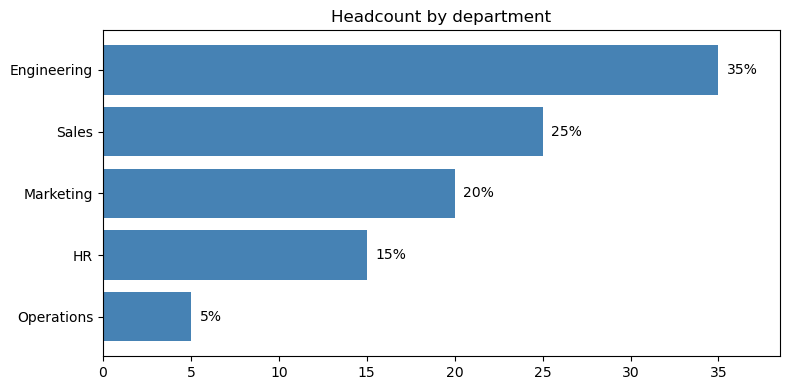

In [35]:
sizes  = [35, 25, 20, 15, 5]
labels = ['Engineering', 'Sales', 'Marketing', 'HR', 'Operations']

order = np.argsort(sizes)
sizes_sorted  = [sizes[i] for i in order]
labels_sorted = [labels[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels_sorted, sizes_sorted, color='steelblue')

for bar, value in zip(bars, sizes_sorted):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{value}%',
            va='center')

ax.set_title("Headcount by department")
ax.set_xlim(0, max(sizes) * 1.1)
plt.tight_layout()
plt.show()

- `np.argsort(sizes)` returns the indices that would sort `sizes` in ascending order. For `[35, 25, 20, 15, 5]` it returns `[4, 3, 2, 1, 0]` (5 is at index 4, then 15 at index 3, and so on).
- The two list comprehensions reorder `sizes` and `labels` using those indices. Sorted ascending means the largest bar ends up at the top — usually the more readable orientation for horizontal bars.
- The text loop is the same value-on-bar trick from the bar-chart section. `va='center'` (vertical alignment) centers each label vertically within its bar.

Compare the two outputs: with bars you can read off the exact percentages quickly and instantly see who's bigger than whom. With the pie chart you have to squint.

## When to Use Which Plot

| Goal | Best plot |
|---|---|
| Trend over time | Line plot |
| Relationship between 2 variables | Scatter plot |
| Compare values across categories | Bar chart |
| Distribution of one variable | Histogram |
| Compare distributions across groups | Box plot or violin plot |
| Composition / parts of a whole | Stacked bar (rarely a pie) |
| Correlation matrix | Heatmap |
| Multi-dimensional data | Scatter with size + color, or a small-multiples grid |

The single best habit when picking a plot type: write down the question you want the reader to answer, then pick the chart that answers that question fastest. The right plot type isn't the one that shows the most data — it's the one the reader can interpret in a couple of seconds.

## Practice Exercises

### Exercise 1
Plot three sine waves on the same axes: `sin(x)`, `sin(2x)`, `sin(3x)` for x from 0 to 2π. Use different line styles and colors, and add a legend.

### Exercise 2
Create a scatter plot of 300 random points colored by which quadrant they fall in:
- Q1: x ≥ 0 and y ≥ 0
- Q2: x < 0 and y ≥ 0
- Q3: x < 0 and y < 0
- Q4: x ≥ 0 and y < 0

### Exercise 3
Create a grouped bar chart comparing four students' grades across three subjects (Math, Science, English). Make up the numbers.

### Exercise 4
Generate 1000 samples from a normal distribution with mean 100 and standard deviation 15. Plot a histogram with 40 bins and overlay vertical lines at the mean and at the 25th and 75th percentiles.

### Exercise 5 (challenge)
Generate five groups of normally distributed data with different means and spreads. Create a single figure with two subplots side by side: a box plot on the left and a violin plot on the right, both showing the same five groups.

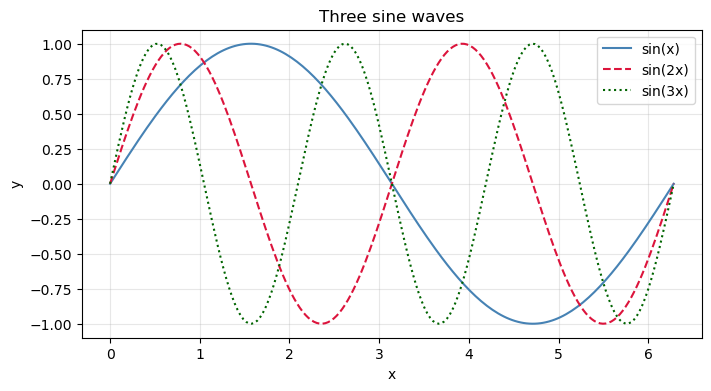

In [36]:
# Exercise 1
x = np.linspace(0, 2*np.pi, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sin(x),   color='steelblue', linestyle='-',  label='sin(x)')
ax.plot(x, np.sin(2*x), color='crimson',   linestyle='--', label='sin(2x)')
ax.plot(x, np.sin(3*x), color='darkgreen', linestyle=':',  label='sin(3x)')
ax.set_title("Three sine waves")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

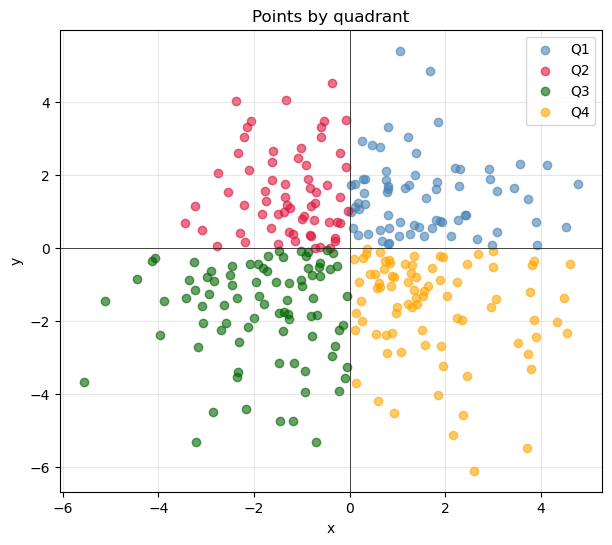

In [37]:
# Exercise 2
np.random.seed(0)
x = np.random.randn(300) * 2
y = np.random.randn(300) * 2

quadrant = np.zeros(len(x), dtype=int)
quadrant[(x >= 0) & (y >= 0)] = 1
quadrant[(x <  0) & (y >= 0)] = 2
quadrant[(x <  0) & (y <  0)] = 3
quadrant[(x >= 0) & (y <  0)] = 4

colors = ['gray', 'steelblue', 'crimson', 'darkgreen', 'orange']
fig, ax = plt.subplots(figsize=(7, 6))
for q in [1, 2, 3, 4]:
    mask = quadrant == q
    ax.scatter(x[mask], y[mask], color=colors[q], alpha=0.6, label=f'Q{q}')

ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_title("Points by quadrant")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

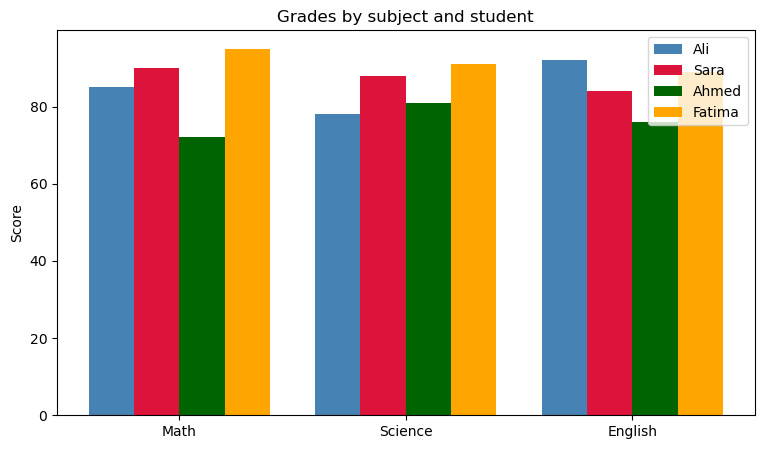

In [38]:
# Exercise 3
subjects = ['Math', 'Science', 'English']
ali     = [85, 78, 92]
sara    = [90, 88, 84]
ahmed   = [72, 81, 76]
fatima  = [95, 91, 89]

x = np.arange(len(subjects))
w = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*w, ali,    w, label='Ali',    color='steelblue')
ax.bar(x - 0.5*w, sara,   w, label='Sara',   color='crimson')
ax.bar(x + 0.5*w, ahmed,  w, label='Ahmed',  color='darkgreen')
ax.bar(x + 1.5*w, fatima, w, label='Fatima', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.set_title("Grades by subject and student")
ax.set_ylabel("Score")
ax.legend()
plt.show()

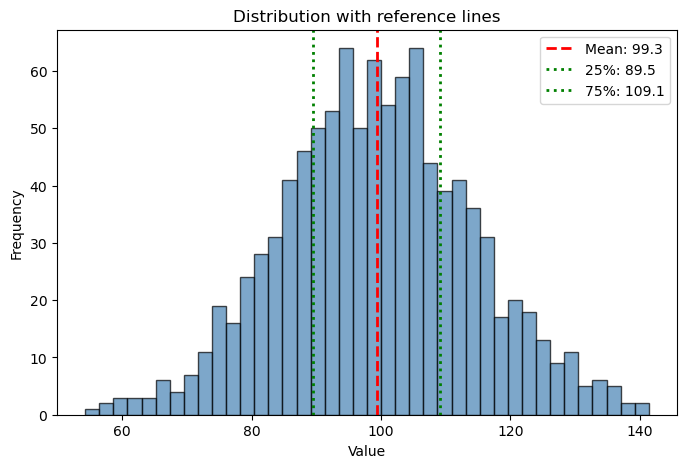

In [39]:
# Exercise 4
np.random.seed(0)
data = np.random.normal(100, 15, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data, bins=40, color='steelblue', edgecolor='black', alpha=0.7)

q25, q75 = np.percentile(data, [25, 75])
mean = data.mean()
ax.axvline(mean, color='red',   linestyle='--', linewidth=2, label=f'Mean: {mean:.1f}')
ax.axvline(q25,  color='green', linestyle=':',  linewidth=2, label=f'25%: {q25:.1f}')
ax.axvline(q75,  color='green', linestyle=':',  linewidth=2, label=f'75%: {q75:.1f}')

ax.set_title("Distribution with reference lines")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_74404\1464782756.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=labels)


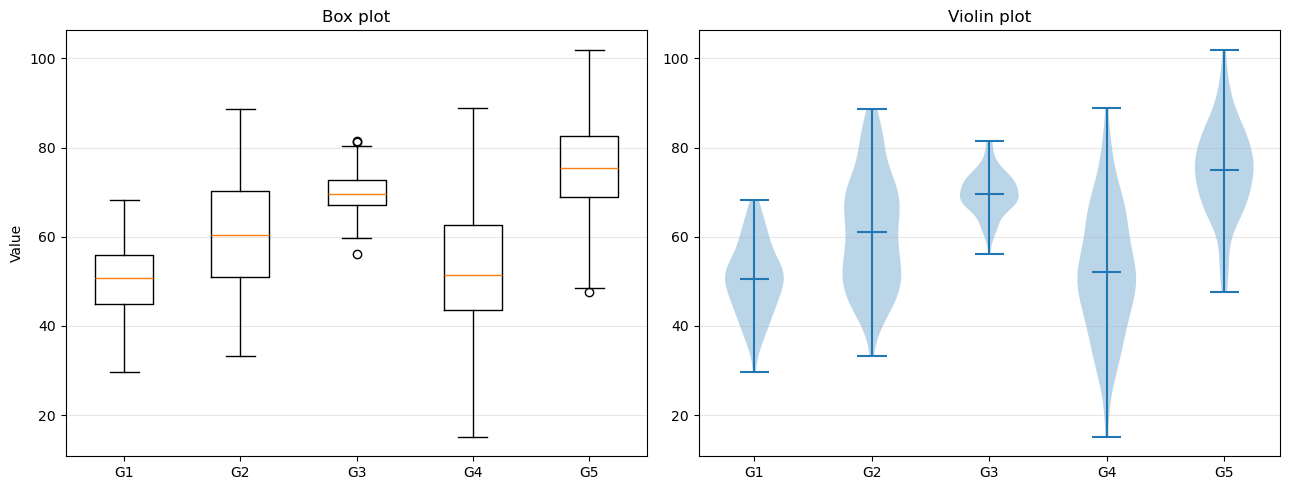

In [40]:
# Exercise 5
np.random.seed(0)
groups = [
    np.random.normal(50,  8, 100),
    np.random.normal(60, 12, 100),
    np.random.normal(70,  5, 100),
    np.random.normal(55, 15, 100),
    np.random.normal(75, 10, 100),
]
labels = [f'G{i+1}' for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(groups, labels=labels)
axes[0].set_title("Box plot")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].violinplot(groups, showmeans=True)
axes[1].set_xticks(range(1, 6))
axes[1].set_xticklabels(labels)
axes[1].set_title("Violin plot")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary

You now have seven plot types in your toolkit:

- **Line plots** for trends and ordered data, with full control over color, line style, width, and markers
- **Scatter plots** for relationships between variables, with optional size and color encoding for extra dimensions
- **Bar charts** in four flavors: vertical, horizontal, grouped, stacked
- **Histograms** for the shape of a single distribution
- **Box and violin plots** for comparing distributions across groups
- **Pie charts** for the rare occasion you need one, and the bar-chart alternative that usually works better
- **A reference table** for picking the right type given the question you're trying to answer

The next notebook covers customization — colors, colormaps, tick formatting, annotations, style sheets, fonts, and removing chart junk.